In [ ]:
!pip uninstall -y onnxruntime onnxruntime-gpu
!pip install -q --upgrade pip

!pip install -q "onnxruntime-gpu[cuda,cudnn]==1.22.0" insightface==0.7.3 opencv-python-headless matplotlib pandas tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import onnxruntime as ort

print("Torch CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Preload CUDA/cuDNN library untuk ONNX Runtime GPU
if hasattr(ort, "preload_dlls"):
    ort.preload_dlls()

print("ONNX Runtime version:", ort.__version__)
print("Available providers:", ort.get_available_providers())

Torch CUDA available: True
GPU: Tesla T4
ONNX Runtime version: 1.22.0
Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [ ]:
import cv2
import numpy as np
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from insightface.app import FaceAnalysis
from google.colab.patches import cv2_imshow

PROJECT_DIR = Path("/content/drive/MyDrive/face_recognition_demo")

KNOWN_FACES_DIR = PROJECT_DIR / "known_faces"
TEST_IMAGES_DIR = PROJECT_DIR / "test_images"
DB_PATH = PROJECT_DIR / "face_db.pkl"

MODEL_NAME = "buffalo_l"
THRESHOLD = 0.45

IMG_EXTENSIONS = ["*.jpg", "*.jpeg", "*.png", "*.webp"]

print("Project dir:", PROJECT_DIR)
print("known_faces ada?", KNOWN_FACES_DIR.exists())
print("test_images ada?", TEST_IMAGES_DIR.exists())

print("Isi known_faces:", os.listdir(KNOWN_FACES_DIR))
print("Isi test_images:", os.listdir(TEST_IMAGES_DIR))

Project dir: /content/drive/MyDrive/face_recognition_demo
known_faces ada? True
test_images ada? True
Isi known_faces: ['Minji', 'Kroos', 'Radit']
Isi test_images: ['test_1.jpg', 'test_2.jpg', 'test_3.jpg', 'test_4.jpg', 'test_5.jpg', 'test_6.jpg', 'test_7.jpg', 'test_8 (1).jpg', 'test_8.jpg', 'test_9.jpg', 'test_10.jpg']


In [ ]:
app = FaceAnalysis(
    name=MODEL_NAME,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

app.prepare(ctx_id=0, det_size=(640, 640))

print("InsightFace siap menggunakan GPU.")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 99654.61KB/s] 


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [ ]:
def list_image_files(folder: Path):
    files = []
    for ext in IMG_EXTENSIONS:
        files.extend(folder.glob(ext))
    return sorted(files)


def get_largest_face_embedding(img_path):
    """
    Ambil embedding dari wajah terbesar dalam gambar.
    Return:
    - emb: embedding wajah L2-normalized
    - img: gambar asli
    """
    img = cv2.imread(str(img_path))

    if img is None:
        print(f"[WARN] Gambar tidak bisa dibaca: {img_path}")
        return None, None

    faces = app.get(img)

    if not faces:
        print(f"[WARN] Tidak ada wajah ditemukan di: {img_path.name}")
        return None, img

    face = max(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
    )

    emb = face.embedding
    emb = emb / np.linalg.norm(emb)

    return emb, img

In [ ]:
def build_database():
    db = {}

    for person_dir in sorted(KNOWN_FACES_DIR.iterdir()):
        if not person_dir.is_dir():
            continue

        person_name = person_dir.name
        image_files = list_image_files(person_dir)

        embeddings = []

        print(f"\nMemproses identitas: {person_name}")

        for img_path in tqdm(image_files):
            emb, _ = get_largest_face_embedding(img_path)

            if emb is not None:
                embeddings.append(emb)

        if embeddings:
            mean_emb = np.stack(embeddings).mean(axis=0)
            mean_emb = mean_emb / np.linalg.norm(mean_emb)

            db[person_name] = mean_emb

            print(f"Terdaftar: {person_name} ({len(embeddings)} foto valid)")
        else:
            print(f"[SKIP] Tidak ada wajah valid untuk {person_name}")

    with open(DB_PATH, "wb") as f:
        pickle.dump(db, f)

    print(f"\nDatabase disimpan ke: {DB_PATH}")
    print(f"Jumlah identitas: {len(db)}")
    print("Identitas:", list(db.keys()))

    return db

In [ ]:
db = build_database()


Memproses identitas: Kroos


100%|██████████| 3/3 [00:08<00:00,  2.67s/it]


Terdaftar: Kroos (3 foto valid)

Memproses identitas: Minji


100%|██████████| 3/3 [00:01<00:00,  1.72it/s]


Terdaftar: Minji (3 foto valid)

Memproses identitas: Radit


100%|██████████| 3/3 [00:03<00:00,  1.01s/it]


Terdaftar: Radit (3 foto valid)

Database disimpan ke: /content/drive/MyDrive/face_recognition_demo/face_db.pkl
Jumlah identitas: 3
Identitas: ['Kroos', 'Minji', 'Radit']


In [ ]:
with open(DB_PATH, "rb") as f:
    db = pickle.load(f)

print("Identitas di database:", list(db.keys()))

Identitas di database: ['Kroos', 'Minji', 'Radit']


In [ ]:
test_files = list_image_files(TEST_IMAGES_DIR)

print("Jumlah test image:", len(test_files))
for p in test_files:
    print(p.name)

Jumlah test image: 11
test_1.jpg
test_10.jpg
test_2.jpg
test_3.jpg
test_4.jpg
test_5.jpg
test_6.jpg
test_7.jpg
test_8 (1).jpg
test_8.jpg
test_9.jpg


In [ ]:
def preview_test_images(cols=5):
    test_files = list_image_files(TEST_IMAGES_DIR)
    rows = int(np.ceil(len(test_files) / cols))

    plt.figure(figsize=(15, 3 * rows))

    for i, img_path in enumerate(test_files):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

preview_test_images(cols=5)

In [ ]:
TEST_LABELS = {
    "test_1.jpg": "Kroos",
    "test_2.jpg": "unknown",
    "test_3.jpg": "Minji",
    "test_4.jpg": "unknown",
    "test_5.jpg": "unknown",
    "test_6.jpg": "unknown",
    "test_7.jpg": "Unknown",
    "test_8.jpg": "Minji",
    "test_9.jpg": "Unknown",
    "test_10.jpg": "Unknown",
}

In [ ]:
for img_path in test_files:
    print(img_path.name, "=>", TEST_LABELS.get(img_path.name, "BELUM ADA LABEL"))

test_1.jpg => Kroos
test_10.jpg => Unknown
test_2.jpg => unknown
test_3.jpg => Minji
test_4.jpg => unknown
test_5.jpg => unknown
test_6.jpg => unknown
test_7.jpg => Unknown
test_8 (1).jpg => BELUM ADA LABEL
test_8.jpg => Minji
test_9.jpg => Unknown


In [ ]:
TEST_LABELS = {
    "test_1.jpg": "Kroos",
    "test_2.jpg": "unknown",
    "test_3.jpg": "Minji",
    "test_4.jpg": "unknown",
    "test_5.jpg": "unknown",
    "test_6.jpg": "unknown",
    "test_7.jpg": "Unknown",
    "test_8.jpg": "Minji",
    "test_8 (1).jpg": "unknown",
    "test_9.jpg": "Unknown",
    "test_10.jpg": "Unknown",
}

In [ ]:
for img_path in test_files:
    print(img_path.name, "=>", TEST_LABELS.get(img_path.name, "BELUM ADA LABEL"))

test_1.jpg => Kroos
test_10.jpg => Unknown
test_2.jpg => unknown
test_3.jpg => Minji
test_4.jpg => unknown
test_5.jpg => unknown
test_6.jpg => unknown
test_7.jpg => Unknown
test_8 (1).jpg => unknown
test_8.jpg => Minji
test_9.jpg => Unknown


In [ ]:
def recognize_test_images(db, threshold=0.45):
    rows = []

    test_files = list_image_files(TEST_IMAGES_DIR)

    for img_path in tqdm(test_files, desc="Testing images"):
        true_label = TEST_LABELS.get(img_path.name, "UNLABELED")

        emb, _ = get_largest_face_embedding(img_path)

        if emb is None:
            rows.append({
                "image": img_path.name,
                "true_label": true_label,
                "predicted_label": "No Face",
                "best_match": None,
                "best_similarity": None,
                "is_correct": False
            })
            continue

        similarities = {}

        for name, ref_emb in db.items():
            similarities[name] = float(np.dot(emb, ref_emb))

        best_match = max(similarities, key=similarities.get)
        best_similarity = similarities[best_match]

        if best_similarity >= threshold:
            predicted_label = best_match
        else:
            predicted_label = "Unknown"

        if true_label == "Unknown":
            is_correct = predicted_label == "Unknown"
        else:
            is_correct = predicted_label == true_label

        rows.append({
            "image": img_path.name,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "best_match": best_match,
            "best_similarity": best_similarity,
            "is_correct": is_correct
        })

    return pd.DataFrame(rows)

In [ ]:
df_results = recognize_test_images(db, threshold=THRESHOLD)
df_results

Testing images: 100%|██████████| 11/11 [00:00<00:00, 11.87it/s]


,image,true_label,predicted_label,best_match,best_similarity,is_correct
0,test_1.jpg,Kroos,Kroos,Kroos,0.823531,True
1,test_10.jpg,Unknown,Unknown,Radit,-0.002512,True
2,test_2.jpg,unknown,Unknown,Kroos,-0.022630,False
3,test_3.jpg,Minji,Minji,Minji,0.643106,True
4,test_4.jpg,unknown,Unknown,Kroos,0.037562,False
5,test_5.jpg,unknown,Unknown,Minji,0.028431,False
6,test_6.jpg,unknown,Unknown,Kroos,0.055505,False
7,test_7.jpg,Unknown,Unknown,Minji,0.062202,True
8,test_8 (1).jpg,unknown,Unknown,Kroos,0.022179,False
9,test_8.jpg,Minji,Minji,Minji,0.637804,True


In [ ]:
accuracy = df_results["is_correct"].mean()
print(f"Akurasi pada threshold {THRESHOLD}: {accuracy:.2%}")

Akurasi pada threshold 0.45: 54.55%


In [ ]:
def show_recognition_image(img_path, db, threshold=0.45):
    img = cv2.imread(str(img_path))

    if img is None:
        print("Gambar tidak bisa dibaca.")
        return

    faces = app.get(img)

    for face in faces:
        x1, y1, x2, y2 = [int(v) for v in face.bbox]

        query_emb = face.embedding
        query_emb = query_emb / np.linalg.norm(query_emb)

        best_name = "Unknown"
        best_sim = -1.0

        for name, ref_emb in db.items():
            sim = float(np.dot(query_emb, ref_emb))

            if sim > best_sim:
                best_sim = sim
                best_name = name

        if best_sim >= threshold:
            label = f"{best_name} ({best_sim:.2f})"
            color = (0, 200, 0)
        else:
            label = f"Unknown ({best_sim:.2f})"
            color = (0, 0, 220)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    cv2_imshow(img)

In [ ]:
show_recognition_image(TEST_IMAGES_DIR / "test_1.jpg", db, threshold=0.45)

In [ ]:
for img_path in list_image_files(TEST_IMAGES_DIR):
    print(img_path.name)
    show_recognition_image(img_path, db, threshold=0.45)

In [ ]:
def collect_similarity_pairs(db):
    rows = []

    test_files = list_image_files(TEST_IMAGES_DIR)

    for img_path in tqdm(test_files, desc="Collecting similarity pairs"):
        true_label = TEST_LABELS.get(img_path.name, "UNLABELED")

        emb, _ = get_largest_face_embedding(img_path)

        if emb is None:
            continue

        for ref_name, ref_emb in db.items():
            sim = float(np.dot(emb, ref_emb))

            if true_label == ref_name:
                pair_type = "genuine"
            else:
                pair_type = "impostor"

            rows.append({
                "image": img_path.name,
                "true_label": true_label,
                "ref_name": ref_name,
                "similarity": sim,
                "pair_type": pair_type
            })

    return pd.DataFrame(rows)

In [ ]:
df_pairs = collect_similarity_pairs(db)
df_pairs

,image,true_label,ref_name,similarity,pair_type
0,test_1.jpg,Kroos,Kroos,0.823531,genuine
1,test_1.jpg,Kroos,Minji,0.067462,impostor
2,test_1.jpg,Kroos,Radit,0.052423,impostor
3,test_10.jpg,Unknown,Kroos,-0.032062,impostor
4,test_10.jpg,Unknown,Minji,-0.067386,impostor
5,test_10.jpg,Unknown,Radit,-0.002512,impostor
6,test_2.jpg,unknown,Kroos,-0.022630,impostor
7,test_2.jpg,unknown,Minji,-0.026289,impostor
8,test_2.jpg,unknown,Radit,-0.072953,impostor
9,test_3.jpg,Minji,Kroos,0.033569,impostor


In [ ]:
df_pairs["pair_type"].value_counts()

,count
pair_type,
impostor,30
genuine,3


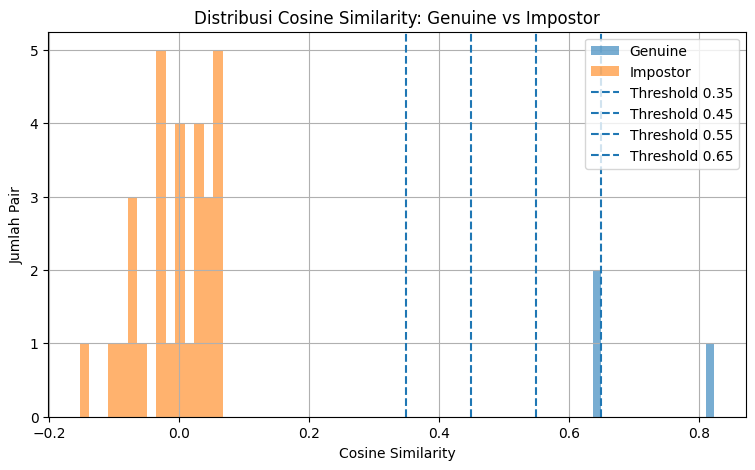

In [ ]:
plt.figure(figsize=(9, 5))

genuine = df_pairs[df_pairs["pair_type"] == "genuine"]["similarity"]
impostor = df_pairs[df_pairs["pair_type"] == "impostor"]["similarity"]

plt.hist(genuine, bins=15, alpha=0.6, label="Genuine")
plt.hist(impostor, bins=15, alpha=0.6, label="Impostor")

plt.axvline(0.35, linestyle="--", label="Threshold 0.35")
plt.axvline(0.45, linestyle="--", label="Threshold 0.45")
plt.axvline(0.55, linestyle="--", label="Threshold 0.55")
plt.axvline(0.65, linestyle="--", label="Threshold 0.65")

plt.xlabel("Cosine Similarity")
plt.ylabel("Jumlah Pair")
plt.title("Distribusi Cosine Similarity: Genuine vs Impostor")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def threshold_analysis(df_pairs, thresholds):
    rows = []

    genuine = df_pairs[df_pairs["pair_type"] == "genuine"]
    impostor = df_pairs[df_pairs["pair_type"] == "impostor"]

    for threshold in thresholds:
        false_reject = (genuine["similarity"] < threshold).sum()
        true_accept = (genuine["similarity"] >= threshold).sum()

        false_accept = (impostor["similarity"] >= threshold).sum()
        true_reject = (impostor["similarity"] < threshold).sum()

        genuine_total = len(genuine)
        impostor_total = len(impostor)

        far = false_accept / impostor_total if impostor_total > 0 else 0
        frr = false_reject / genuine_total if genuine_total > 0 else 0

        rows.append({
            "threshold": threshold,
            "true_accept": true_accept,
            "false_reject": false_reject,
            "true_reject": true_reject,
            "false_accept": false_accept,
            "FAR": far,
            "FRR": frr
        })

    return pd.DataFrame(rows)

In [ ]:
thresholds = np.arange(0.20, 0.81, 0.05)

df_thresholds = threshold_analysis(df_pairs, thresholds)
df_thresholds

,threshold,true_accept,false_reject,true_reject,false_accept,FAR,FRR
0,0.20,3,0,30,0,0.0,0.000000
1,0.25,3,0,30,0,0.0,0.000000
2,0.30,3,0,30,0,0.0,0.000000
3,0.35,3,0,30,0,0.0,0.000000
4,0.40,3,0,30,0,0.0,0.000000
5,0.45,3,0,30,0,0.0,0.000000
6,0.50,3,0,30,0,0.0,0.000000
7,0.55,3,0,30,0,0.0,0.000000
8,0.60,3,0,30,0,0.0,0.000000
9,0.65,1,2,30,0,0.0,0.666667


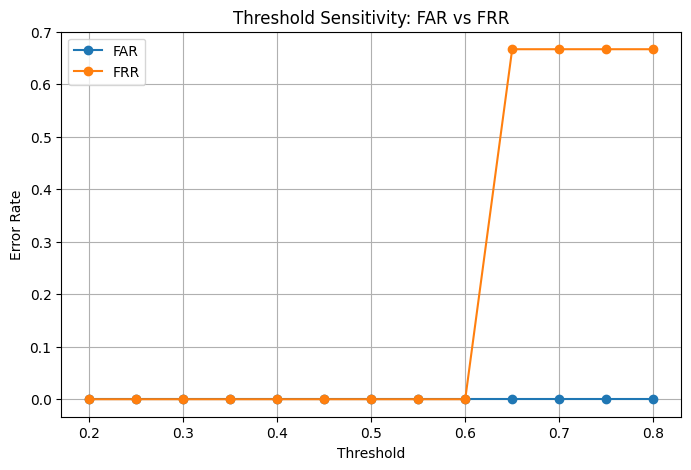

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(df_thresholds["threshold"], df_thresholds["FAR"], marker="o", label="FAR")
plt.plot(df_thresholds["threshold"], df_thresholds["FRR"], marker="o", label="FRR")

plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("Threshold Sensitivity: FAR vs FRR")
plt.legend()
plt.grid(True)
plt.show()